# HerBERT – Analiza Sentymentu i Sarkazmu

## Importy

In [ ]:
#Komórkę można pominąć/ usunąć, jeśli naprawiono błędy najnowszej wersji biblioteki datasets
!pip uninstall -y torchvision

import os
os.environ["DATASETS_DISABLE_TORCHVISION"] = "1"

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import Dataset
from transformers import AutoModel, AutoTokenizer, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import json
from safetensors.torch import load_file
import time


#Ścieżki
MODEL_NAME = "allegro/herbert-base-cased"
MODEL_SAVE_PATH = "/content/drive/MyDrive/Herbert1.4/herbert_sentiment_final"
TRAINING_OUTPUT_DIR = "/content/drive/MyDrive/Herbert1.4/herbert_sentiment_model"

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Definicja modelu


In [ ]:
class HerBERTSentimentSarcasm(nn.Module):

    def __init__(self, model_name, num_sentiment_labels, num_sarcasm_labels=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size

        self.sarcasm_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
        )

        self.dropout = nn.Dropout(0.1)
        self.classifier_sentiment = nn.Linear(hidden_size, num_sentiment_labels)
        self.classifier_sarcasm = nn.Linear(hidden_size, num_sarcasm_labels)

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        token_type_ids=None,
        labels_sentiment=None,
        labels_sarcasm=None,
    ):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )

        pooled_output = self.dropout(outputs.last_hidden_state[:, 0, :])

        h_sarc = self.sarcasm_head(pooled_output)
        logits_sarcasm  = self.classifier_sarcasm(h_sarc)
        logits_sentiment = self.classifier_sentiment(pooled_output)

        loss = None
        if labels_sentiment is not None and labels_sarcasm is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss_sent = loss_fct(logits_sentiment, labels_sentiment)
            loss_sarc = loss_fct(logits_sarcasm,   labels_sarcasm)
            loss = loss_sent + 0.7 * loss_sarc

        return {
            "loss": loss,
            "logits": logits_sentiment,
            "logits_sentiment": logits_sentiment,
            "logits_sarcasm": logits_sarcasm,
        }

print("Klasa modelu zdefiniowana.")

Klasa modelu zdefiniowana.


## Funkcje pomocnicze

In [ ]:
def load_and_prepare_data(main_path, sarcasm_path):
    df = pd.read_excel(main_path)
    df = df.dropna(subset=["Treść", "Sentyment", "Sarkazm"])

    print(f"Komentarze ogólne wierszy: {len(df)}")
    print(f"Rozkład sentymentu:\n{df['Sentyment'].value_counts()}\n")

    df_sarcasm = pd.read_excel(sarcasm_path)
    df_synth = df_sarcasm[["Treść", "Sentyment", "Sarkazm"]].copy()

    df_aug = pd.concat([df, df_synth], ignore_index=True)

    print(f"Po połączeniu wierszy: {len(df_aug)}")
    print(f"Rozkład sentymentu:\n{df_aug['Sentyment'].value_counts()}\n")

    le_sent = LabelEncoder()
    df_aug["label_sentiment"] = le_sent.fit_transform(df_aug["Sentyment"])

    df_aug["Sarkazm"] = df_aug["Sarkazm"].fillna(0)
    df_aug["label_sarcasm"] = df_aug["Sarkazm"].astype(int)

    return df_aug, le_sent

def split_data(df_aug):
    X_train, X_test, y_sent_train, y_sent_test, y_sarc_train, y_sarc_test = train_test_split(
        df_aug["Treść"].values,
        df_aug["label_sentiment"].values,
        df_aug["label_sarcasm"].values,
        test_size=0.2,
        random_state=42,
        stratify=df_aug["label_sentiment"],
    )

    train_df = pd.DataFrame({
        "text": X_train,
        "label_sentiment": y_sent_train,
        "label_sarcasm": y_sarc_train,
    })
    test_df = pd.DataFrame({
        "text": X_test,
        "label_sentiment": y_sent_test,
        "label_sarcasm": y_sarc_test,
    })

    print(f"Treningowy: {len(train_df)}, Testowy: {len(test_df)}")
    return train_df, test_df, y_sent_test, y_sarc_test


def tokenize_datasets(train_df, test_df, tokenizer):
    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    def tokenize_function(examples):
        enc = tokenizer(
            examples["text"],
            padding='max_length',
            truncation=True,
            max_length=256,
        )
        enc["labels_sentiment"] = examples["label_sentiment"]
        enc["labels_sarcasm"] = examples["label_sarcasm"]
        return enc

    train_tokenized = train_dataset.map(tokenize_function, batched=True)
    test_tokenized = test_dataset.map(tokenize_function,  batched=True)

    cols_to_remove = {"text", "label_sentiment", "label_sarcasm", "__index_level_0__"}
    train_tokenized = train_tokenized.remove_columns(
        list(cols_to_remove & set(train_tokenized.column_names))
    )
    test_tokenized = test_tokenized.remove_columns(
        list(cols_to_remove & set(test_tokenized.column_names))
    )

    train_tokenized.set_format("torch")
    test_tokenized.set_format("torch")

    print(f"Kolumny po tokenizacji: {train_tokenized.column_names}")
    return train_tokenized, test_tokenized


def compute_metrics(eval_pred):
    preds = eval_pred.predictions
    labels = eval_pred.label_ids
    logits_sent = preds[0]
    labels_sent = labels[0]
    pred_sent = np.argmax(logits_sent, axis=-1)

    return {
        "accuracy": accuracy_score(labels_sent, pred_sent),
        "f1_sentiment_macro": f1_score(labels_sent, pred_sent, average="macro"),
    }


def plot_confusion_matrix(y_true, y_pred, labels, title, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels,
    )
    plt.xlabel("Przewidywany sentyment")
    plt.ylabel("Rzeczywisty sentyment")
    plt.title(title)
    plt.tight_layout()
    if save_path is not None:
      plt.savefig(save_path, dpi=150)
      print(f"Macierz pomyłek zapisana do: {save_path}")
    plt.show()


def predict_sentiment_sarcasm(
    texts,
    model,
    tokenizer,
    le_sent,
    device=None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    if isinstance(texts, str):
        texts = [texts]

    inputs = tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors="pt",
    ).to(device)

    model.eval()
    model.to(device)

    with torch.no_grad():
        out = model(**inputs)
        probs_sent = F.softmax(out["logits_sentiment"], dim=-1).cpu().numpy()
        probs_sarc = F.softmax(out["logits_sarcasm"],   dim=-1).cpu().numpy()

    results = []
    for i, text in enumerate(texts):
        sent_id = np.argmax(probs_sent[i])
        sarc_id = np.argmax(probs_sarc[i])
        sent_label = le_sent.inverse_transform([sent_id])[0]
        sarc_label = "sarkastyczny" if sarc_id == 1 else "niesarkastyczny"
        confidence_sarc = probs_sarc[i].max()

        if confidence_sarc < 0.5:
            status = "niejednoznaczne"
        elif confidence_sarc < 0.7:
            status = "umiarkowana pewność"
        else:
            status = "pewne"

        row = {
            "tekst": text[:100] + "..." if len(text) > 100 else text,
            "sentyment": sent_label,
            "pewność_sarkazmu": f"{confidence_sarc:.2%}",
            "sarkazm": sarc_label,
            "status_sarkazmu": status,
        }
        for j, label in enumerate(le_sent.classes_):
            row[f"P_sent({label})"] = f"{probs_sent[i][j]:.2%}"
        row["P_sarkazm(0)"] = f"{probs_sarc[i][0]:.2%}"
        row["P_sarkazm(1)"] = f"{probs_sarc[i][1]:.2%}"
        results.append(row)

    return pd.DataFrame(results)


print("Funkcje zdefiniowane.")

Funkcje zdefiniowane.


## Wczytanie danych i trening

Komentarze ogólne wierszy: 1576
Rozkład sentymentu:
Sentyment
Pozytywny    914
Negatywny    372
Neutralny    290
Name: count, dtype: int64

Po połączeniu wierszy: 2284
Rozkład sentymentu:
Sentyment
Pozytywny    995
Negatywny    918
Neutralny    371
Name: count, dtype: int64

Treningowy: 1827, Testowy: 457


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/907k [00:00<?, ?B/s]

...

[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Sentiment Macro
1,0.536058,0.347587,0.908096,0.898122
2,0.257605,0.439815,0.912473,0.905253
3,0.057204,0.485147,0.919037,0.910362
4,0.021431,0.423448,0.929978,0.922086


Training Loss,Validation Loss,Epoch,Accuracy,F1 Sentiment Macro
0.021431,0.423448,4,0.929978,0.922086



 wyniki ewaluacji
eval_loss: 0.4234
eval_accuracy: 0.9300
eval_f1_sentiment_macro: 0.9221



 raport klasyfikacji
              precision    recall  f1-score   support

   Negatywny       0.95      0.93      0.94       184
   Neutralny       0.95      0.84      0.89        74
   Pozytywny       0.91      0.96      0.93       199

    accuracy                           0.93       457
   macro avg       0.94      0.91      0.92       457
weighted avg       0.93      0.93      0.93       457

Macierz pomyłek zapisana do: /content/drive/MyDrive/Herbert1.4/confusion_matrix.png


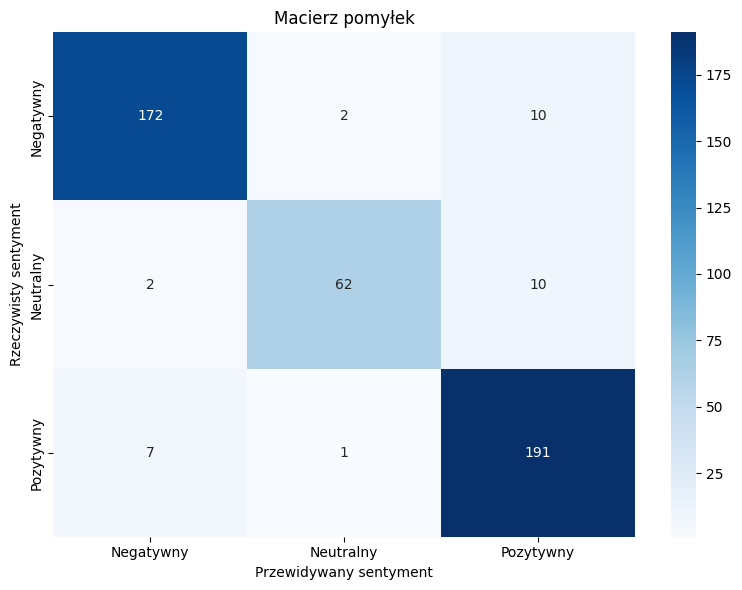

In [ ]:
start_time = time.time()

df_aug, le_sent = load_and_prepare_data(
    main_path="/content/drive/MyDrive/KomentarzeSM/komentarze.xlsx",
    sarcasm_path="/content/drive/MyDrive/KomentarzeSM/sarkazm.xlsx",
)
sentiment_names = le_sent.classes_

train_df, test_df, y_sent_test, y_sarc_test = split_data(df_aug)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_tokenized, test_tokenized = tokenize_datasets(train_df, test_df, tokenizer)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Urządzenie: {device}")

num_sentiment_labels = len(sentiment_names)
model = HerBERTSentimentSarcasm(MODEL_NAME, num_sentiment_labels=num_sentiment_labels)
model.to(device)
training_args = TrainingArguments(
    output_dir=MODEL_SAVE_PATH,
    eval_strategy="epoch",
    logging_strategy="steps",
    logging_steps=25,
    save_strategy="epoch",
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_sentiment_macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics,
)

trainer.train()

results = trainer.evaluate()
print("\n wyniki ewaluacji")
for key, value in results.items():
    print(f"{key}: {value:.4f}")

predictions = trainer.predict(test_tokenized)
logits_sent = predictions.predictions[0]
y_sent_pred = np.argmax(logits_sent, axis=-1)

print("\n raport klasyfikacji")
print(classification_report(y_sent_test, y_sent_pred, target_names=sentiment_names))

plot_confusion_matrix(
    y_sent_test, y_sent_pred,
    labels=sentiment_names,
    title="Macierz pomyłek",
    save_path="/content/drive/MyDrive/Herbert1.4/confusion_matrix.png",
)

## Zapis modelu na dysk

In [ ]:
trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

classes_path = os.path.join(MODEL_SAVE_PATH, "label_classes.json")
with open(classes_path, "w", encoding="utf-8") as f:
    json.dump(le_sent.classes_.tolist(), f, ensure_ascii=False)

print(f"Model zapisany w: {MODEL_SAVE_PATH}")
print(f"Klasy sentymentu zapisane w: {classes_path}")
print(f"Pliki w folderze: {os.listdir(MODEL_SAVE_PATH)}")

Model zapisany w: /content/drive/MyDrive/Herbert1.4/herbert_sentiment_final
Klasy sentymentu zapisane w: /content/drive/MyDrive/Herbert1.4/herbert_sentiment_final/label_classes.json
Pliki w folderze: ['checkpoint-229', 'checkpoint-458', 'checkpoint-687', 'checkpoint-916', 'model.safetensors', 'label_classes.json', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json']


## Wczytanie zapisanego modelu

In [ ]:
classes_path = os.path.join(MODEL_SAVE_PATH, "label_classes.json")
with open(classes_path, "r", encoding="utf-8") as f:
    saved_classes = json.load(f)

le_sent = LabelEncoder()
le_sent.classes_ = np.array(saved_classes)
sentiment_names  = le_sent.classes_

tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_PATH)

safetensors_path = os.path.join(MODEL_SAVE_PATH, "model.safetensors")
bin_path = os.path.join(MODEL_SAVE_PATH, "pytorch_model.bin")

device = "cuda" if torch.cuda.is_available() else "cpu"

model = HerBERTSentimentSarcasm(
    MODEL_NAME,
    num_sentiment_labels=len(sentiment_names),
)

if os.path.exists(safetensors_path):
    state_dict = load_file(safetensors_path, device=device)
    model.load_state_dict(state_dict)
    print("Wagi wczytane")
elif os.path.exists(bin_path):
    state_dict = torch.load(bin_path, map_location=device)
    model.load_state_dict(state_dict)
    print("Wagi wczytane")
else:
    raise FileNotFoundError(f"Nie znaleziono pliku")

model.to(device)
model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wagi wczytane


HerBERTSentimentSarcasm(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, eleme

## Klasyfikacji komentarzy


In [ ]:
nowe_komentarze = [
    "Ten filmik serio mnie zdenerwował",
    "Z roku na rok ta liga robi się coraz mniej ciekawa, ale dalej oglądam z przyzwyczajenia.",
    "Ktoś jeszcze ma wrażenie, że te wszystkie aktualizacje są robione tylko pod reklamę?",
    "Dawno nie widziałem tak spokojnej i merytorycznej dyskusji w komentarzach, szacun dla wszystkich.",
    "No tak, bo przecież influencer z TikToka na pewno zna się lepiej niż lekarz.",
    "To jest dokładnie ten typ treści, przez który mam ochotę wyłączyć internet na tydzień.",
    "Naprawdę fajnie, że pokazujesz też kulisy, a nie tylko idealne momenty.",
    "Mam mieszane uczucia, pomysł super, ale wykonanie wygląda jak robione w pośpiechu.",
    "Świetny montaż, aż trudno uwierzyć, że to zrobione na telefonie.",
    "Kolejny odcinek o tym samym, zaczyna się robić trochę nudno.",
]

wyniki = predict_sentiment_sarcasm(
    nowe_komentarze,
    model=model,
    tokenizer=tokenizer,
    le_sent=le_sent,
)

display(wyniki)

,tekst,sentyment,pewność_sarkazmu,sarkazm,status_sarkazmu,P_sent(Negatywny),P_sent(Neutralny),P_sent(Pozytywny),P_sarkazm(0),P_sarkazm(1)
0,Ten filmik serio mnie zdenerwował,Negatywny,100.00%,niesarkastyczny,pewne,53.71%,0.16%,46.14%,100.00%,0.00%
1,Z roku na rok ta liga robi się coraz mniej cie...,Pozytywny,100.00%,niesarkastyczny,pewne,0.18%,0.40%,99.42%,100.00%,0.00%
2,"Ktoś jeszcze ma wrażenie, że te wszystkie aktu...",Neutralny,99.99%,niesarkastyczny,pewne,10.61%,89.30%,0.09%,99.99%,0.01%
3,Dawno nie widziałem tak spokojnej i merytorycz...,Pozytywny,100.00%,niesarkastyczny,pewne,0.01%,0.01%,99.98%,100.00%,0.00%
4,"No tak, bo przecież influencer z TikToka na pe...",Negatywny,100.00%,sarkastyczny,pewne,99.91%,0.02%,0.07%,0.00%,100.00%
5,"To jest dokładnie ten typ treści, przez który ...",Negatywny,99.85%,niesarkastyczny,pewne,88.25%,0.02%,11.73%,99.85%,0.15%
6,"Naprawdę fajnie, że pokazujesz też kulisy, a n...",Pozytywny,99.51%,niesarkastyczny,pewne,0.01%,0.00%,99.99%,99.51%,0.49%
7,"Mam mieszane uczucia, pomysł super, ale wykona...",Neutralny,99.98%,niesarkastyczny,pewne,0.06%,99.84%,0.10%,99.98%,0.02%
8,"Świetny montaż, aż trudno uwierzyć, że to zrob...",Negatywny,99.96%,sarkastyczny,pewne,98.99%,0.01%,1.00%,0.04%,99.96%
9,"Kolejny odcinek o tym samym, zaczyna się robić...",Negatywny,100.00%,niesarkastyczny,pewne,99.17%,0.70%,0.13%,100.00%,0.00%


In [ ]:
end_time = time.time()
elapsed = end_time - start_time

minutes = int(elapsed // 60)
seconds = elapsed % 60

device = "GPU T4" if torch.cuda.is_available() else "CPU"

print(f"\nŚrodowisko wykonawcze:{device}")
print(f"\nCałkowity czas wykonania: {minutes} min {seconds:.1f} s")


Środowisko wykonawcze:GPU T4

Całkowity czas wykonania: 7 min 59.4 s
